# 📉 Do Activist Short-Seller Reports Move Stock Prices? An Event Study

Activist short sellers such as Hindenburg Research, Muddy Waters and Citron publish detailed reports accusing a public company of fraud, accounting tricks or a hopelessly inflated valuation — after taking a short position in its stock. Their critics call it "short and distort"; their supporters point to cases like Nikola and Valeant as proof that they catch what auditors and regulators miss.

This notebook asks what actually happens to the target's stock price after a report is published.

**Data**
- `short-seller-reports.csv`: a hand-compiled list of 48 short-seller reports (2002–2024) with the target, ticker, publication date, a summary of the allegations, a narrative "Impact to the Company" note, and a link to each report.
- Daily dividend- and split-adjusted prices from [Yahoo Finance](https://finance.yahoo.com/) via [`yfinance`](https://github.com/ranaroussi/yfinance), cached to `stock-prices.csv` so the numbers are reproducible.

**Questions**
1. How much does a target's stock fall when the report comes out, and relative to the market?
2. Does that drop persist, deepen or reverse over the following year?
3. Do the results differ by research firm?
4. How many targets can't be studied because they went bankrupt, were acquired or changed tickers — and how does that bias the results?
5. How accurate are the hand-written "Impact" claims when checked against price data?

In [1]:
import pandas as pd
import numpy as np
import yfinance as yf

In [2]:
df = pd.read_csv(
    'short-seller-reports.csv',
    parse_dates=['Date Published']
)
df.drop(columns=['#'], inplace=True)

df

,Title,Target Company,Research Firm,Stock Exchange,Ticker,Date Published,Allegations,Impact to the Company,LINK
0,Nikola: How to Parlay An Ocean of Lies Into a ...,Nikola Corporation,Hindenburg Research,NASDAQ,NKLA,2020-09-10,Hindenburg Research published a report accusin...,"Nikola's shares fell more than 40%, and the C...",https://hindenburgresearch.com/nikola/
1,Valeant: Could this be the Pharmaceutical Enron?,Valeant Pharmaceuticals,Citron Research,NYSE,BHC,2015-10-21,Citron accused Valeant of fraudulently inflati...,Valeant Plunges 30% After Short Seller Citron ...,https://citronresearch.com/wp-content/uploads/...
2,Usana: You DO NOT Have the Right to Remain Silent,USANA Health Sciences,Citron Research,NASDAQ,USNA,2012-11-29,Citron claimed that USANA’s business model was...,USANA’s stock dropped by over 25%.,https://citronresearch.com/wp-content/uploads/...
3,Muddy Waters Initiating Coverage on ONP – Stro...,Orient Paper Inc.,Muddy Waters Research,NYSE,ONP,2010-06-28,Muddy Waters accused Orient Paper of inflating...,"The stock dropped more than 50%, setting the s...",https://muddywatersresearch.com/research/orien...
4,Initiating Coverage on NQ Mobile Inc. (NYSE: N...,NQ Mobile Inc,Muddy Waters Research,NYSE,NQ,2013-10-24,The report accused NQ Mobile of being a “massi...,NQ Mobile’s stock plummeted by over 50%.,https://muddywatersresearch.com/research/nq/in...
5,GoPro Price Target $30 Within 12 Months.\r\nCi...,GoPro Inc,Citron Research,NASDAQ,GPRO,2014-11-04,Citron claimed GoPro’s business model was unsu...,"GoPro’s stock dropped over 30%, and it has sin...",https://citronresearch.com/wp-content/uploads/...
6,MW is Short Burford Capital Ltd. (BUR LN),Burford Capital Limited,Muddy Waters Research,NYSE,BUR\r,2019-08-07,Claimed Burford overstated profits and used ag...,Burford’s shares plunged nearly 50% following ...,https://muddywatersresearch.com/research/bur/m...
7,GDS Holdings Limited│ NASDAQ: GDS,GDS Holdings Limited,Blue Orca Capital,NASDAQ,GDS,2018-07-30,Blue Orca alleged that GDS inflated its revenu...,GDS’s stock dropped over 15% shortly after the...,https://static1.squarespace.com/static/5a81b55...
8,The “World’s Most Powerful Quantum Computer” I...,IONQ Inc,Scorpion Capital,NYSE,IONQ,2022-05-03,The report claims that the company's 32-qubit ...,IONQ Stock Falls 10% Following Scorpion Capita...,https://scorpioncapital.s3.us-east-2.amazonaws...
9,A Pump and Dump SPAC Scam By Silicon\r\nValley...,Quantumscape Corp,Scorpion Capital,NYSE,QS,2021-04-15,Scorpion alleged that QuantumScape’s battery t...,QuantumScape’s stock dropped by around 12% fol...,https://scorpioncapital.s3.us-east-2.amazonaws...


In [3]:
df['Research Firm'].value_counts()

Research Firm
Hindenburg Research            25
Muddy Waters Research          11
Scorpion Capital                6
Citron Research                 3
Blue Orca Capital               1
Greenlight Capital              1
Herb Greenberg, MarketWatch     1
Name: count, dtype: int64

The list has **48 reports from 7 firms**, and Hindenburg Research alone accounts for 25 of them. (The `#` column runs from 1 to 48 but is blank for the Eros report, so it was dropped.) The three firms with a single report each will be grouped together later, since nothing can be learned from n = 1.

The cell below was the original starting point: download a year of prices for the first report (Nikola).

In [4]:
for index, row in df[:1].iterrows():
    target = row['Target Company']
    ticker = row['Ticker']
    date_published = row['Date Published']
    start_date = date_published.strftime("%Y-%m-%d")
    end_date = date_published + pd.Timedelta(days=365)
    end_date = end_date.strftime("%Y-%m-%d")
    
    print(f'index={index}, target={target}, \
ticker={ticker}, start_date={start_date}, end_date={end_date}')

    # Fetch the stock data using yfinance
    stock_data = yf.download(ticker, start=start_date, end=end_date)
    
    display(stock_data)

index=0, target=Nikola Corporation, ticker=NKLA, start_date=2020-09-10, end_date=2021-09-10


HTTP Error 404: Not Found{"quoteSummary":{"result":null,"error":{"code":"Not Found","description":"Quote not found for symbol: NKLA"}}}


$NKLA: possibly delisted; no timezone found


[*********************100%***********************]  1 of 1 completed



1 Failed download:


['NKLA']: possibly delisted; no timezone found


Price,Adj Close,Close,High,Low,Open,Volume
Ticker,NKLA,NKLA,NKLA,NKLA,NKLA,NKLA


The Nikola download now comes back **empty**. Nikola filed for Chapter 11 in February 2025 and Yahoo Finance no longer serves its price history, even for 2020–2021. The most famous report in the list can no longer be studied with free data. That is the central data problem in this study: **the targets that collapsed completely are the ones most likely to disappear from the price record.** The rest of the notebook builds a full event study and keeps track of what is missing and why.

## 🔧 Building the Event Study

### Setup

In [5]:
import os

import plotly.express as px
import plotly.graph_objects as go
import plotly.io as pio
from scipy import stats

pio.templates['sans_serif'] = go.layout.Template(dict(layout=go.Layout(
    font_family='Helvetica, Inter, Arial, sans-serif')))
pio.templates.default = 'simple_white+sans_serif'

pd.set_option('display.max_columns', 20)
pd.set_option('display.width', 200)

ACCENT = '#D1495B'   # single accent color; everything else is black or gray
GRAY = '#9E9E9E'
LIGHT_GRAY = '#D9D9D9'

### Cleaning the report list

The CSV has a few problems that would quietly break a price lookup:
- `Ticker` for Burford is `'BUR\r'` (a stray carriage return), and `Research Firm` has `'Blue Orca Capital '` with a trailing space.
- **The GDS publication date is off by one day.** Blue Orca published on July 31, 2018, and that is the day GDS fell 37%. On the CSV's date (July 30) GDS fell only 6%. For the other reports, the CSV date lines up with the price record: the sell-off comes on day 0 or the day after. A sample of dates was also checked against news coverage.
- The `Stock Exchange` column is not reliable either. JOYY (YY) trades on Nasdaq rather than NYSE, CCME was a Nasdaq stock, and in 2019 Burford traded only in London. The analysis doesn't use this column.

In [6]:
reports = df.copy()

# Stray whitespace: 'BUR\r' in Ticker and 'Blue Orca Capital ' in Research Firm
text_cols = ['Target Company', 'Research Firm', 'Stock Exchange', 'Ticker']
reports[text_cols] = reports[text_cols].apply(lambda s: s.str.strip())

# Publication-date correction: Blue Orca's GDS report came out on July 31, 2018,
# the day GDS fell 37% (the CSV says July 30)
DATE_FIXES = {'GDS': '2018-07-31'}
for ticker, fixed_date in DATE_FIXES.items():
    reports.loc[reports['Ticker'] == ticker, 'Date Published'] = pd.Timestamp(fixed_date)

print(f"{len(reports)} reports, {reports['Date Published'].min():%Y-%m-%d} to {reports['Date Published'].max():%Y-%m-%d}")
reports['Date Published'].dt.year.value_counts().sort_index().to_frame('reports').T

48 reports, 2002-06-17 to 2024-10-08


Date Published,2002,2005,2010,2011,2012,2013,2014,2015,2017,2018,2019,2020,2021,2022,2023,2024
reports,1,1,1,1,1,1,1,1,1,2,1,9,10,8,6,3


Activity is concentrated in the recent past: 27 of the 48 reports came out between 2020 and 2022, the era of SPACs, EV start-ups and meme stocks.

### Ticker mapping: following companies that changed names

Ten targets now trade under a different ticker, or (in Burford's case) traded only in London at the time of the report. Valeant is listed too: the CSV already uses its current ticker, BHC, and Yahoo's BHC history runs back through the years it traded as VRX. Each mapping below points to the **same company's continuous price history**, not to a new company that took over an old ticker. The day-0 drops computed later match the drops described in the CSV's own "Impact" notes (e.g., JOYY −26.5% vs. "down more than 26%"; Burford −46% vs. "nearly 50%"), which confirms that each mapping points to the right security.

In [7]:
TICKER_MAP = pd.DataFrame([
    ('BHC',  'BHC',   'Valeant traded as VRX in 2015; Yahoo keeps the full history under the current ticker (Bausch Health)'),
    ('ONP',  'ITP',   'Orient Paper was renamed IT Tech Packaging'),
    ('BUR',  'BUR.L', 'In 2019 Burford traded only on London AIM (NYSE listing came in Oct 2020); benchmark = FTSE AIM All-Share'),
    ('SQ',   'XYZ',   'Block changed its ticker from SQ to XYZ in Jan 2025'),
    ('YY',   'JOYY',  'JOYY ADSs now trade on Nasdaq as JOYY'),
    ('AILE', 'AILEQ', 'iLearningEngines filed for Chapter 11 in Dec 2024; history continues under the OTC ticker'),
    ('TIO',  'TIOG',  'Tingo Group was delisted from Nasdaq; history continues under the OTC ticker'),
    ('MULN', 'BINI',  'Mullen Automotive was renamed Bollinger Innovations; serial reverse splits are absorbed by adjusted prices'),
    ('XL',   'SPRU',  'XL Fleet was renamed Spruce Power'),
    ('GNUS', 'TOON',  'Genius Brands was renamed Kartoon Studios'),
    ('EROS', 'EMWPF', 'Eros International became Eros STX Global, then Eros Media World (OTC); one continuous price history'),
], columns=['Ticker', 'yf_ticker', 'note'])

reports = reports.merge(TICKER_MAP[['Ticker', 'yf_ticker']], on='Ticker', how='left')
reports['yf_ticker'] = reports['yf_ticker'].fillna(reports['Ticker'])
reports['benchmark'] = np.where(reports['yf_ticker'].str.endswith('.L'), '^FTAI', 'SPY')

with pd.option_context('display.max_colwidth', 120):
    display(TICKER_MAP)

,Ticker,yf_ticker,note
0,BHC,BHC,Valeant traded as VRX in 2015; Yahoo keeps the full history under the current ticker (Bausch Health)
1,ONP,ITP,Orient Paper was renamed IT Tech Packaging
2,BUR,BUR.L,In 2019 Burford traded only on London AIM (NYSE listing came in Oct 2020); benchmark = FTSE AIM All-Share
3,SQ,XYZ,Block changed its ticker from SQ to XYZ in Jan 2025
4,YY,JOYY,JOYY ADSs now trade on Nasdaq as JOYY
5,AILE,AILEQ,iLearningEngines filed for Chapter 11 in Dec 2024; history continues under the OTC ticker
6,TIO,TIOG,Tingo Group was delisted from Nasdaq; history continues under the OTC ticker
7,MULN,BINI,Mullen Automotive was renamed Bollinger Innovations; serial reverse splits are absorbed by adjusted prices
8,XL,SPRU,XL Fleet was renamed Spruce Power
9,GNUS,TOON,Genius Brands was renamed Kartoon Studios


### Downloading prices (with a local cache)

For every report we download about 40 trading days before publication through about 275 trading days after it. We also download benchmarks: **SPY** for US listings, the **FTSE AIM All-Share** index (`^FTAI`) for Burford's London listing, and **IWM** (Russell 2000) and **ARKK** (a speculative-growth ETF) for a robustness check.

Notes on the download:
- `auto_adjust=True` makes every price split- and dividend-adjusted, which matters here. Mullen (now BINI) did so many reverse splits that its adjusted 2022 prices are around 10¹⁵ dollars, but returns, which are price *ratios*, are unaffected.
- Recent `yfinance` versions return `(Price, Ticker)` MultiIndex columns even for a single ticker, so the helper drops the `Ticker` level when it is present.
- Yahoo re-computes adjusted prices whenever a company pays a dividend or splits its stock. The first run therefore writes everything to `stock-prices.csv` (columns `ticker, date, adj_close, adj_low`), and later runs read from that file, so the numbers in this notebook don't drift.

In [8]:
PRICE_CACHE = 'stock-prices.csv'
WINDOW_BEFORE = pd.Timedelta(days=60)    # ~40 trading days before publication
WINDOW_AFTER = pd.Timedelta(days=400)    # ~275 trading days after publication

def download_prices(ticker, start, end):
    """Daily dividend- and split-adjusted close (and low) from Yahoo Finance, as a tidy frame."""
    raw = yf.download(ticker, start=start, end=end, auto_adjust=True, progress=False)
    if raw.empty:
        return pd.DataFrame(columns=['ticker', 'date', 'adj_close', 'adj_low'])
    if isinstance(raw.columns, pd.MultiIndex):     # recent yfinance returns (Price, Ticker) columns
        raw = raw.droplevel('Ticker', axis=1)
    out = (raw[['Close', 'Low']]
           .rename(columns={'Close': 'adj_close', 'Low': 'adj_low'})
           .dropna(subset=['adj_close'])
           .rename_axis('date')
           .reset_index())
    out.insert(0, 'ticker', ticker)
    return out

if os.path.exists(PRICE_CACHE):
    prices = pd.read_csv(PRICE_CACHE, parse_dates=['date'])
    print(f'Loaded cached prices from {PRICE_CACHE}')
else:
    frames = [download_prices(r['yf_ticker'], r['Date Published'] - WINDOW_BEFORE, r['Date Published'] + WINDOW_AFTER)
              for _, r in reports.iterrows()]
    # Benchmarks: SPY (main) plus IWM and ARKK (robustness) for US listings; FTSE AIM All-Share for Burford
    for bench, group in reports.groupby('benchmark'):
        start, end = group['Date Published'].min() - WINDOW_BEFORE, group['Date Published'].max() + WINDOW_AFTER
        for ticker in (['SPY', 'IWM', 'ARKK'] if bench == 'SPY' else [bench]):
            frames.append(download_prices(ticker, start, end))
    prices = pd.concat([f for f in frames if len(f)], ignore_index=True)
    prices.to_csv(PRICE_CACHE, index=False, float_format='%.8g')
    print(f'Downloaded prices and saved them to {PRICE_CACHE}')

print(f"{len(prices):,} rows, {prices['ticker'].nunique()} tickers")
prices.head()

Loaded cached prices from stock-prices.csv
26,988 rows, 42 tickers


,ticker,date,adj_close,adj_low
0,BHC,2015-08-24,220.25000,200.02000
1,BHC,2015-08-25,220.08000,218.96001
2,BHC,2015-08-26,227.24001,217.77000
3,BHC,2015-08-27,234.89999,228.39999
4,BHC,2015-08-28,236.12000,232.03999


### Coverage: which reports can we actually study?

In [9]:
prices_by_ticker = {t: g.set_index('date').sort_index() for t, g in prices.groupby('ticker')}

NO_DATA_REASON = {
    'NKLA': 'Filed for Chapter 11 in Feb 2025; Yahoo no longer serves NKLA history',
    'NQ':   'Renamed Link Motion (LKM), later delisted; no history under either ticker',
    'CCME': 'Delisted from NASDAQ in 2011 after its auditor resigned',
    'KDNY': 'Acquired by Novartis in Aug 2023 ($40/share in cash)',
    'BLI':  'Renamed PhenomeX, then acquired by Bruker in 2023',
    'RENB': 'No longer quoted on Yahoo Finance',
    'EBIX': 'Filed for Chapter 11 in Dec 2023 and delisted',
    'RIDE': 'Filed for Chapter 11 in Jun 2023; successor ticker NRDE has no 2021-22 history',
    'AFC':  'Acquired by Ares Capital in 2010',
    'DNUT': 'In 2005 Krispy Kreme traded as KKD (taken private in 2016); DNUT is the 2021 re-IPO',
}

def longest_flat_run(close):
    """Longest streak of unchanged closes: a trading halt or a stale quote after trading stopped."""
    flat = close.diff().eq(0)
    return int(flat.groupby((~flat).cumsum()).sum().max())

coverage = reports[['Ticker', 'yf_ticker', 'Target Company', 'Research Firm', 'Date Published']].copy()
coverage['trading_days'] = coverage['yf_ticker'].map(lambda t: len(prices_by_ticker.get(t, [])))
coverage['usable'] = coverage['trading_days'] > 0
coverage['longest_flat_run'] = coverage['yf_ticker'].map(
    lambda t: longest_flat_run(prices_by_ticker[t]['adj_close']) if t in prices_by_ticker else np.nan)
coverage['reason'] = coverage['Ticker'].map(NO_DATA_REASON)

print(f"Usable: {coverage['usable'].sum()} of {len(coverage)} reports")
display(coverage.groupby('usable', as_index=False).agg(reports=('Ticker', 'size')))
(coverage.query('~usable')
 [['Ticker', 'Target Company', 'Research Firm', 'Date Published', 'reason']]
 .sort_values('Date Published')
 .style.format({'Date Published': '{:%Y-%m-%d}'})
 .hide(axis='index'))

Usable: 38 of 48 reports


,usable,reports
0,False,10
1,True,38


Ticker,Target Company,Research Firm,Date Published,reason
AFC,Allied Capital,Greenlight Capital,2002-06-17,Acquired by Ares Capital in 2010
DNUT,Krispy Kreme Inc,"Herb Greenberg, MarketWatch",2005-05-02,In 2005 Krispy Kreme traded as KKD (taken private in 2016); DNUT is the 2021 re-IPO
CCME,"China MediaExpress Holdings, Inc.",Muddy Waters Research,2011-02-03,Delisted from NASDAQ in 2011 after its auditor resigned
NQ,NQ Mobile Inc,Muddy Waters Research,2013-10-24,"Renamed Link Motion (LKM), later delisted; no history under either ticker"
NKLA,Nikola Corporation,Hindenburg Research,2020-09-10,Filed for Chapter 11 in Feb 2025; Yahoo no longer serves NKLA history
RIDE,Lordstown Motors Corporation,Hindenburg Research,2021-03-12,Filed for Chapter 11 in Jun 2023; successor ticker NRDE has no 2021-22 history
BLI,Berkeley Lights,Scorpion Capital,2021-09-15,"Renamed PhenomeX, then acquired by Bruker in 2023"
EBIX,Ebix Inc,Hindenburg Research,2022-06-16,Filed for Chapter 11 in Dec 2023 and delisted
KDNY,Chinook Therapeutics Inc,Muddy Waters Research,2023-05-16,Acquired by Novartis in Aug 2023 ($40/share in cash)
RENB,Renovaro Inc,Hindenburg Research,2024-02-13,No longer quoted on Yahoo Finance


**38 of 48 reports (79%) have usable prices. The 10 that don't are not a random sample:**
- **5 ended in bankruptcy or delisting**: Nikola, Lordstown Motors, Ebix, China MediaExpress and NQ Mobile/Link Motion. A complete collapse is exactly the outcome a short seller is betting on. Nikola's founder resigned within two weeks of the report and was later convicted of fraud, and China MediaExpress was delisted within months.
- **3 were acquired**: Allied Capital (2010, Ares), Berkeley Lights/PhenomeX (2023, Bruker) and Chinook Therapeutics (2023, Novartis). Chinook cuts the other way. Novartis agreed to pay $40 a share less than a month after Muddy Waters' report, while the CSV puts the pre-report price at $23.40.
- **2 are data gaps**: Krispy Kreme's 2005 shares (then `KKD`) have no relation to today's `DNUT`, and Renovaro is no longer quoted on Yahoo.

**Survivorship bias:** free price databases quietly drop dead companies. Because the missing group is dominated by bankruptcies and delistings, the returns measured below **probably understate** how badly targets did on average, even though one missing target (Chinook) was a clear win for shareholders. Firms also lose different shares of their reports: Hindenburg loses 4 of 25, Muddy Waters 3 of 11, Scorpion 1 of 6, and both pre-2010 reports are gone.

### Halted or stale prices

Yahoo fills days without trades by repeating the last price. A run of 10 or more identical closes signals a trading halt, or a stock that stopped trading.

In [10]:
def flat_run_span(close):
    """First and last date of the longest streak of unchanged closes."""
    flat = close.diff().eq(0)
    run_id = (~flat).cumsum()
    days = close.index[run_id == flat.groupby(run_id).sum().idxmax()]
    return days[1], days[-1]          # days[0] is the last real price change

stale_events = coverage.query('longest_flat_run >= 10').copy()
stale_events[['flat_from', 'flat_to']] = [flat_run_span(prices_by_ticker[t]['adj_close']) for t in stale_events['yf_ticker']]
(stale_events[['Ticker', 'yf_ticker', 'Date Published', 'longest_flat_run', 'flat_from', 'flat_to']]
 .rename(columns={'longest_flat_run': 'unchanged closes (days)'})
 .style.format({'Date Published': '{:%Y-%m-%d}', 'flat_from': '{:%Y-%m-%d}', 'flat_to': '{:%Y-%m-%d}',
                'unchanged closes (days)': '{:.0f}'})
 .hide(axis='index'))

Ticker,yf_ticker,Date Published,unchanged closes (days),flat_from,flat_to
WORX,WORX,2020-04-17,76,2020-04-22,2020-08-07
AILE,AILEQ,2024-08-29,188,2025-01-02,2025-10-02
TIO,TIOG,2023-06-06,73,2023-11-14,2024-02-29


Three usable events have this problem:
- **SCWorx (WORX)** shows an unchanged price for 76 trading days, starting three trading days after the report (April 22, 2020). That is consistent with a trading halt. Its +5, +21 and +63 day returns therefore carry the last pre-halt price.
- **Tingo (TIO)** shows an unchanged price for 73 days from November 2023. When prices resume in March 2024, the stock is trading over the counter for a few cents.
- **iLearningEngines (AILE)** has no price changes after December 31, 2024, weeks after its Chapter 11 filing, so its 6-month and 1-year values are that last trade.

In all three cases the repeated price is the last real trade, i.e. the "last available price" rule commonly used for delisted stocks. They are kept in the sample, and the robustness check below shows the results without them.

### Event-study returns

Definitions used throughout:
- **Day 0** = the first trading day on or after the publication date. **Baseline** = the close on the last trading day *before* publication, because many reports drop before the open or during trading.
- **Raw return** at day *t* = close(*t*) / baseline − 1, measured at *t* = 0, +5, +21, +63, +126 and +252 trading days (one day, one week, one month, three months, six months and one year).
- **Abnormal return** = raw return − the benchmark's return over the same dates. This is a market-adjusted, *buy-and-hold* abnormal return. A stock can lose at most 100%, but its abnormal return can fall below −100% when it is wiped out while the market rises. Seven targets end the year below −100% for this reason.

The eight biggest day-0 drops:

In [11]:
HORIZONS = [0, 5, 21, 63, 126, 252]   # day 0, 1 week, 1 month, 3 months, 6 months, 1 year

paths, rows = [], []
for _, r in reports.iterrows():
    s = prices_by_ticker.get(r['yf_ticker'])
    if s is None:
        continue
    bench = prices_by_ticker[r['benchmark']]['adj_close'].reindex(s.index).ffill()
    day0 = s.index.searchsorted(r['Date Published'])   # first trading day on/after publication
    base = day0 - 1                                       # last close BEFORE publication = baseline
    path = pd.DataFrame({
        'Ticker': r['Ticker'],
        'event_day': np.arange(len(s)) - day0,
        'date': s.index,
        'ret': s['adj_close'].to_numpy() / s['adj_close'].iloc[base] - 1,
        'bench_ret': bench.to_numpy() / bench.iloc[base] - 1,
    })
    path['abn_ret'] = path['ret'] - path['bench_ret']    # market-adjusted (buy-and-hold) abnormal return
    paths.append(path)
    rows.append({'Ticker': r['Ticker'],
                 'base_date': s.index[base],
                 'date_252': s.index[day0 + 252] if day0 + 252 < len(s) else pd.NaT,
                 'day0_low': s['adj_low'].iloc[day0] / s['adj_close'].iloc[base] - 1})

event_paths = pd.concat(paths, ignore_index=True)

wide = (event_paths.query('event_day in @HORIZONS')
        .pivot(index='Ticker', columns='event_day', values=['ret', 'abn_ret']))
wide.columns = [f'{kind}_{day}' for kind, day in wide.columns]

events = (reports
          .merge(pd.DataFrame(rows), on='Ticker')
          .merge(wide.reset_index(), on='Ticker'))
print(f'{len(events)} events with prices from day -10 through day +252: '
      f"{events[['abn_ret_0', 'abn_ret_252']].notna().all(axis=1).sum()}")

(events[['Ticker', 'Research Firm', 'Date Published', 'ret_0', 'abn_ret_0', 'ret_252', 'abn_ret_252']]
 .sort_values('abn_ret_0')
 .head(8)
 .style.format({'Date Published': '{:%Y-%m-%d}', 'ret_0': '{:+.1%}', 'abn_ret_0': '{:+.1%}',
                'ret_252': '{:+.1%}', 'abn_ret_252': '{:+.1%}'})
 .hide(axis='index'))

38 events with prices from day -10 through day +252: 38


Ticker,Research Firm,Date Published,ret_0,abn_ret_0,ret_252,abn_ret_252
AILE,Hindenburg Research,2024-08-29,-53.3%,-53.3%,-86.8%,-103.6%
DLO,Muddy Waters Research,2022-11-16,-50.7%,-49.9%,-11.1%,-26.0%
TIO,Hindenburg Research,2023-06-06,-48.2%,-48.5%,-99.6%,-126.6%
BUR,Muddy Waters Research,2019-08-07,-46.0%,-43.8%,-49.4%,-51.1%
PCT,Hindenburg Research,2021-05-06,-39.7%,-40.5%,-66.2%,-67.0%
GDS,Blue Orca Capital,2018-07-31,-37.2%,-37.7%,+15.7%,+8.3%
NTRA,Hindenburg Research,2022-03-09,-32.8%,-35.5%,-1.1%,+4.7%
TGLS,Hindenburg Research,2021-12-09,-36.0%,-35.3%,-10.6%,+4.4%


## 📊 How Much Do Targets Fall, and for How Long?

In [12]:
horizon_summary = pd.DataFrame([{
    'trading days after': h,
    'n': events[f'abn_ret_{h}'].notna().sum(),
    'median raw return': events[f'ret_{h}'].median(),
    'median abnormal': events[f'abn_ret_{h}'].median(),
    'mean abnormal': events[f'abn_ret_{h}'].mean(),
    'share down (raw)': (events[f'ret_{h}'] < 0).mean(),
    'share below benchmark': (events[f'abn_ret_{h}'] < 0).mean(),
    'Wilcoxon p (abnormal = 0)': stats.wilcoxon(events[f'abn_ret_{h}'].dropna()).pvalue,
} for h in HORIZONS])

(horizon_summary.style
 .format({c: '{:+.1%}' for c in ['median raw return', 'median abnormal', 'mean abnormal']}
         | {'share down (raw)': '{:.0%}', 'share below benchmark': '{:.0%}', 'Wilcoxon p (abnormal = 0)': '{:.1e}'})
 .hide(axis='index'))

trading days after,n,median raw return,median abnormal,mean abnormal,share down (raw),share below benchmark,Wilcoxon p (abnormal = 0)
0,38,-12.8%,-13.4%,-18.2%,97%,97%,7.3e-11
5,38,-17.8%,-18.5%,-21.6%,97%,97%,3.6e-11
21,38,-24.5%,-27.8%,-25.7%,79%,79%,1.8e-07
63,38,-29.2%,-31.9%,-26.4%,76%,79%,7.9e-05
126,38,-38.7%,-45.9%,-36.1%,79%,82%,1.0e-05
252,38,-46.8%,-62.2%,-48.0%,76%,79%,4.5e-06


- **The first-day reaction is nearly universal.** 37 of 38 targets (97%) underperformed the benchmark on day 0, with a median abnormal return of **−13.4%**. The one exception is Nano-X, which plunged 23% intraday but closed up 4%.
- **The losses keep growing.** The median abnormal return deepens from −13.4% on day 0 to −27.8% after a month, −45.9% after six months and **−62.2% after a year**. After a year 76% of targets are down in raw terms, and 79% trail the benchmark. A Wilcoxon signed-rank test rejects "no abnormal return" at every horizon (p < 0.0001).
- **Mean vs. median:** on day 0 the mean (−18.2%) is *below* the median because a handful of collapses (iLearningEngines, dLocal, Tingo, Burford) drag it down. At one year the mean (−48.0%) is *above* the median (−62.2%) because one huge winner pulls it up: Roblox ended the year +190% vs. SPY. Without Roblox the 1-year mean would be −54%. With samples this small and this skewed, report the median.

### Distribution of day-0 and 1-year abnormal returns

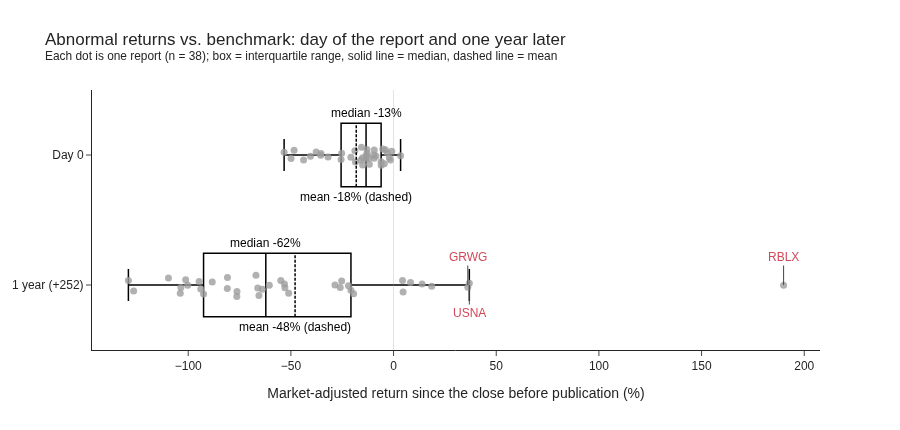

In [13]:
dist = (events.melt(id_vars='Ticker', value_vars=['abn_ret_0', 'abn_ret_252'],
                  var_name='horizon', value_name='abn_ret')
        .assign(horizon=lambda d: d['horizon'].map({'abn_ret_0': 'Day 0', 'abn_ret_252': '1 year (+252)'})))

fig = go.Figure()
for label in ['1 year (+252)', 'Day 0']:
    sub = dist.query('horizon == @label')
    fig.add_trace(go.Box(
        x=sub['abn_ret'] * 100, name=label, orientation='h', boxpoints='all', jitter=0.4, pointpos=0,
        boxmean=True, text=sub['Ticker'], hovertemplate='%{text}: %{x:.1f}%<extra></extra>',
        marker=dict(color=GRAY, size=7, opacity=0.8), line=dict(color='black', width=1.5),
        fillcolor='rgba(0,0,0,0)', showlegend=False))

for label in ['Day 0', '1 year (+252)']:
    sub = dist.query('horizon == @label')['abn_ret'] * 100
    fig.add_annotation(x=sub.median(), y=label, yshift=42, showarrow=False,
                       text=f'median {sub.median():+.0f}%', font=dict(color='black', size=12))
    fig.add_annotation(x=sub.mean(), y=label, yshift=-42, showarrow=False,
                       text=f'mean {sub.mean():+.0f}% (dashed)', font=dict(color='black', size=12))
top = dist.query("horizon == '1 year (+252)' and abn_ret > 0.3").sort_values('abn_ret')
for k, (_, r) in enumerate(top.iterrows()):
    fig.add_annotation(x=r['abn_ret'] * 100, y='1 year (+252)', text=r['Ticker'], showarrow=True,
                       arrowhead=0, ax=0, ay=-28 if k % 2 == 0 else 28, font=dict(color=ACCENT, size=12))

fig.add_vline(x=0, line=dict(color=GRAY, width=1))
fig.update_layout(
    title='Abnormal returns vs. benchmark: day of the report and one year later<br>'
          '<sup>Each dot is one report (n = 38); box = interquartile range, solid line = median, dashed line = mean</sup>',
    xaxis_title='Market-adjusted return since the close before publication (%)', yaxis_title=None,
    height=430, width=900, margin=dict(t=90))
fig.show()

Day-0 abnormal returns range from −53% to +3%. One year later the range is far wider, from −129% to +190%. The report predicts the *direction* of the next year quite well (30 of 38 below the benchmark). It does not predict the *size* of the move, and a few targets (Roblox, GrowGeneration, USANA) rallied hard in spite of it.

### 👉 Cumulative abnormal return in event time

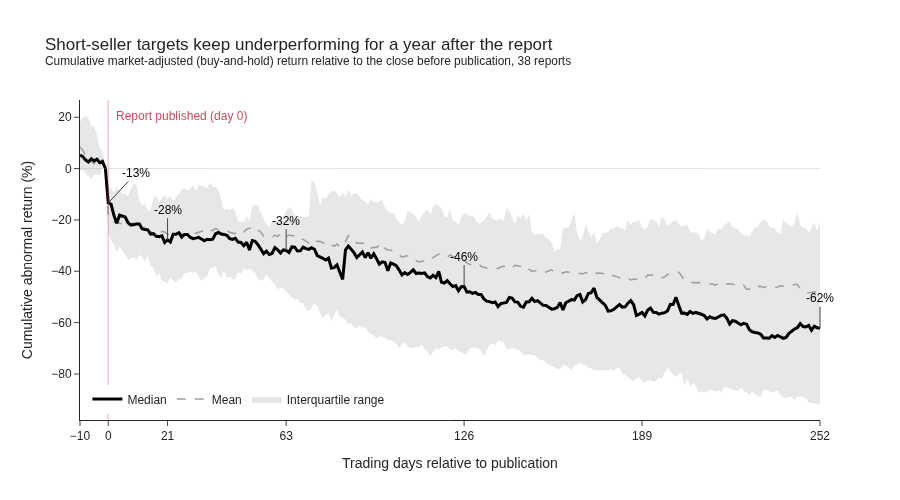

Day -10 vs. baseline: median +5.3%, share of targets whose price was higher 10 days earlier: 68% (Wilcoxon p = 0.010)


In [14]:
car = (event_paths.query('-10 <= event_day <= 252')
       .groupby('event_day', as_index=False)
       .agg(median=('abn_ret', 'median'), mean=('abn_ret', 'mean'),
            q25=('abn_ret', lambda s: s.quantile(0.25)), q75=('abn_ret', lambda s: s.quantile(0.75)),
            n=('abn_ret', 'size')))
car[['median', 'mean', 'q25', 'q75']] *= 100

fig = go.Figure()
fig.add_trace(go.Scatter(x=car['event_day'], y=car['q75'], line=dict(width=0), showlegend=False, hoverinfo='skip'))
fig.add_trace(go.Scatter(x=car['event_day'], y=car['q25'], line=dict(width=0), fill='tonexty',
                         fillcolor='rgba(158,158,158,0.25)', name='Interquartile range', hoverinfo='skip'))
fig.add_trace(go.Scatter(x=car['event_day'], y=car['mean'], name='Mean',
                         line=dict(color=GRAY, width=1.5, dash='dash'),
                         hovertemplate='day %{x}: mean %{y:.1f}%<extra></extra>'))
fig.add_trace(go.Scatter(x=car['event_day'], y=car['median'], name='Median',
                         line=dict(color='black', width=3),
                         hovertemplate='day %{x}: median %{y:.1f}%<extra></extra>'))

fig.add_vline(x=0, line=dict(color=ACCENT, width=1.5))
fig.add_hline(y=0, line=dict(color=GRAY, width=1))
fig.add_annotation(x=0, y=car['q75'].max(), text='Report published (day 0)', showarrow=False,
                   xanchor='left', xshift=6, font=dict(color=ACCENT))
for d in [0, 21, 63, 126, 252]:
    v = car.loc[car['event_day'] == d, 'median'].iloc[0]
    fig.add_annotation(x=d, y=v, text=f'{v:+.0f}%', showarrow=True, arrowhead=0,
                       ax=28 if d == 0 else 0, ay=-30, font=dict(color='black', size=12))

fig.update_layout(
    title='Short-seller targets keep underperforming for a year after the report<br>'
          '<sup>Cumulative market-adjusted (buy-and-hold) return relative to the close before publication, '
          f'{event_paths["Ticker"].nunique()} reports</sup>',
    xaxis_title='Trading days relative to publication', yaxis_title='Cumulative abnormal return (%)',
    height=500, width=900, legend=dict(orientation='h', yanchor='bottom', y=0.02, xanchor='left', x=0.01),
    hovermode='x unified')
fig.update_xaxes(range=[-10, 252], tickvals=[-10, 0, 21, 63, 126, 189, 252])
fig.show()

pre = event_paths.query('event_day == -10')['abn_ret']
print(f'Day -10 vs. baseline: median {pre.median():+.1%}, share of targets whose price was higher 10 days earlier: '
      f'{(pre > 0).mean():.0%} (Wilcoxon p = {stats.wilcoxon(pre).pvalue:.3f})')

- **The drift continues long after day 0.** The median target is −13% on day 0, −28% after a month, −32% after three months, −46% after six months and **−62% after one year**. The market did not absorb the information in a day, which is not what a strictly efficient market would do.
- The interquartile band widens steadily, so outcomes diverge over time. The median keeps falling, while the mean (dashed) declines more slowly and ends at −48%, held up by a few big recoveries.
- **There is a pre-event slide.** Ten trading days before publication the median target stood 5.3% higher (vs. the market) than at the baseline close, and 68% of targets were higher then (Wilcoxon p = 0.010). Possible explanations include short sellers building positions, information leaking, or targets that were already weakening. This data can't tell them apart. The pattern is not uniform: meme-era targets such as Genius Brands, SCWorx and GrowGeneration had *rallied* sharply in the days before their reports.

### Does the initial drop persist or reverse?

Kept falling after day 0: 28 of 38 (74%); median additional abnormal return after day 0: -47.4%
Spearman correlation, day-0 vs. 1-year abnormal return: 0.12 (p = 0.49)


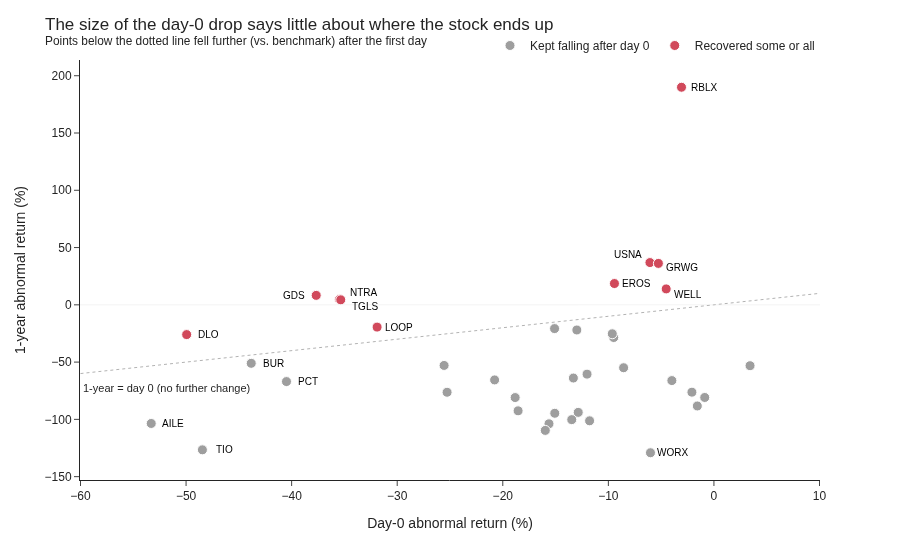

In [15]:
persist = events[['Ticker', 'Research Firm', 'abn_ret_0', 'abn_ret_252']].assign(
    further_drop=lambda d: d['abn_ret_252'] - d['abn_ret_0'],
    outcome=lambda d: np.where(d['abn_ret_252'] < d['abn_ret_0'], 'Kept falling after day 0', 'Recovered some or all'))

rho, p_rho = stats.spearmanr(persist['abn_ret_0'], persist['abn_ret_252'])
print(f"Kept falling after day 0: {(persist['further_drop'] < 0).sum()} of {len(persist)} "
      f"({(persist['further_drop'] < 0).mean():.0%}); median additional abnormal return after day 0: "
      f"{persist['further_drop'].median():+.1%}")
print(f'Spearman correlation, day-0 vs. 1-year abnormal return: {rho:.2f} (p = {p_rho:.2f})')

fig = px.scatter(persist.assign(x=persist['abn_ret_0'] * 100, y=persist['abn_ret_252'] * 100),
                 x='x', y='y', color='outcome', hover_name='Ticker',
                 color_discrete_map={'Kept falling after day 0': GRAY, 'Recovered some or all': ACCENT},
                 labels={'x': 'Day-0 abnormal return (%)', 'y': '1-year abnormal return (%)', 'outcome': ''})
fig.update_traces(marker=dict(size=10, line=dict(color='white', width=1)))
lo, hi = -60, 10
fig.add_shape(type='line', x0=lo, y0=lo, x1=hi, y1=hi, line=dict(color='black', width=1, dash='dot'))
fig.add_annotation(x=lo, y=lo, text='1-year = day 0 (no further change)', showarrow=False, xanchor='left',
                   yshift=-14, font=dict(size=11))
fig.add_hline(y=0, line=dict(color=LIGHT_GRAY, width=1))
LABEL_SHIFT = {'GDS': (-22, 0), 'NTRA': (24, 7), 'TGLS': (24, -7), 'USNA': (-22, 8), 'GRWG': (24, -4), 'WELL': (22, -6)}
for _, r in persist.query('outcome == "Recovered some or all" or Ticker in ["AILE", "TIO", "WORX", "BUR", "PCT"]').iterrows():
    dx, dy = LABEL_SHIFT.get(r['Ticker'], (22, 0))
    fig.add_annotation(x=r['abn_ret_0'] * 100, y=r['abn_ret_252'] * 100, text=r['Ticker'], showarrow=False,
                       xshift=dx, yshift=dy, font=dict(size=10, color='black'))
fig.update_layout(
    title='The size of the day-0 drop says little about where the stock ends up<br>'
          '<sup>Points below the dotted line fell further (vs. benchmark) after the first day</sup>',
    height=560, width=900, legend=dict(orientation='h', yanchor='bottom', y=1.0, xanchor='right', x=1))
fig.show()

- **28 of 38 targets (74%) kept falling after day 0.** The median target lost a further 47 percentage points against the benchmark over the rest of the year.
- **The size of the first-day drop does not predict the 1-year outcome** (Spearman ρ = 0.12, p = 0.49). Some of the biggest day-0 drops reversed: GDS (−38% on day 0), Natera and Tecnoglass (about −35% each) all ended the year at or above the benchmark. Some of the mildest first-day reactions came before the worst years: SCWorx (−6%), and Kandi, XL Fleet and Clover Health (−12% to −16%). The market's first verdict is a poor guide to the eventual one.
- Ten targets recovered at least part of the drop. Eight of them ended the year above the benchmark: Roblox, GrowGeneration, USANA, Eros, Welltower, GDS, Natera and Tecnoglass. Several of these were attacks on established, larger companies (Roblox, Welltower, Natera, USANA) rather than on early-stage hype stocks.

### By research firm (where n allows)

In [16]:
firm_summary = (events
    .assign(firm=lambda d: d['Research Firm'].where(d['Research Firm'].isin(
        ['Hindenburg Research', 'Muddy Waters Research', 'Scorpion Capital']), 'Other (Citron, Blue Orca)'))
    .groupby('firm', as_index=False)
    .agg(reports=('Ticker', 'size'),
         median_day0=('abn_ret_0', 'median'),
         median_1yr=('abn_ret_252', 'median'),
         mean_1yr=('abn_ret_252', 'mean'),
         share_below_benchmark_1yr=('abn_ret_252', lambda s: (s < 0).mean()))
    .sort_values('reports', ascending=False))

display(firm_summary.style
        .format({'median_day0': '{:+.1%}', 'median_1yr': '{:+.1%}', 'mean_1yr': '{:+.1%}',
                 'share_below_benchmark_1yr': '{:.0%}'})
        .hide(axis='index'))

hb = events.query("`Research Firm` == 'Hindenburg Research'")['abn_ret_252']
others = events.query("`Research Firm` != 'Hindenburg Research'")['abn_ret_252']
print(f'Mann-Whitney U, Hindenburg (n={len(hb)}) vs. all other firms (n={len(others)}), 1-year abnormal return: '
      f'p = {stats.mannwhitneyu(hb, others).pvalue:.2f}')

firm,reports,median_day0,median_1yr,mean_1yr,share_below_benchmark_1yr
Hindenburg Research,21,-13.5%,-66.1%,-43.8%,71%
Muddy Waters Research,8,-13.4%,-64.7%,-63.6%,100%
Scorpion Capital,5,-13.3%,-60.5%,-54.3%,100%
"Other (Citron, Blue Orca)",4,-12.3%,-34.0%,-30.9%,50%


Mann-Whitney U, Hindenburg (n=21) vs. all other firms (n=17), 1-year abnormal return: p = 0.81


- Day-0 reactions are almost identical across firms (median −12% to −14%). The market reacts to "a short report" more than to who wrote it.
- At one year, all of Muddy Waters' (8) and Scorpion's (5) usable targets trailed the benchmark, compared with 71% of Hindenburg's 21. The median 1-year abnormal returns are similar (−61% to −66%), and the gap between Hindenburg and all other firms is far from significant (Mann-Whitney p = 0.81). **With 5–8 reports per firm, and with survivorship removing different numbers of each firm's targets, this table does not support ranking the firms.**

### Robustness: is SPY the right benchmark?

Many targets were small, speculative growth stocks, and many reports came out in 2020–2021, right before speculative stocks crashed in 2022. Measured against SPY, part of a target's "abnormal" loss may simply be the style crash. The table repeats the 1-year calculation against small-cap (IWM) and speculative-growth (ARKK) benchmarks for US listings, without the three halted/stale events, and by period.

In [17]:
def one_year_abnormal(bench_ticker):
    """1-year buy-and-hold return minus the benchmark's, on the same dates (US listings only)."""
    bench = prices_by_ticker[bench_ticker]['adj_close']
    out = {}
    for _, r in events.query("benchmark == 'SPY'").iterrows():
        if r['base_date'] >= bench.index.min():
            out[r['Ticker']] = r['ret_252'] - (bench.asof(r['date_252']) / bench.asof(r['base_date']) - 1)
    return pd.Series(out)

stale = stale_events['Ticker']
year = events['Date Published'].dt.year
scenarios = {
    'Main: SPY (FTSE AIM for Burford)': events['abn_ret_252'],
    'Benchmark = IWM (Russell 2000)': one_year_abnormal('IWM'),
    'Benchmark = ARKK (speculative growth)': one_year_abnormal('ARKK'),
    'Excluding 3 events with halted/stale prices': events.loc[~events['Ticker'].isin(stale), 'abn_ret_252'],
    'Reports from 2020-2021 only': events.loc[year.isin([2020, 2021]), 'abn_ret_252'],
    'Reports from other years': events.loc[~year.isin([2020, 2021]), 'abn_ret_252'],
}
robustness = pd.DataFrame([{'scenario': k, 'n': v.notna().sum(), 'median 1-year abnormal': v.median(),
                            'share below benchmark': (v < 0).mean()} for k, v in scenarios.items()])
robustness.style.format({'median 1-year abnormal': '{:+.1%}', 'share below benchmark': '{:.0%}'}).hide(axis='index')

scenario,n,median 1-year abnormal,share below benchmark
Main: SPY (FTSE AIM for Burford),38,-62.2%,79%
Benchmark = IWM (Russell 2000),37,-50.4%,78%
Benchmark = ARKK (speculative growth),35,-29.4%,86%
Excluding 3 events with halted/stale prices,35,-54.9%,77%
Reports from 2020-2021 only,16,-71.7%,88%
Reports from other years,22,-39.8%,73%


- **The underperformance survives every benchmark.** The median 1-year abnormal return shrinks from −62% (SPY) to −50% (IWM) and −29% (ARKK). The share of targets trailing the benchmark stays between 78% and 86%. Even against a fund of the same kind of speculative growth stocks, 86% of targets did worse.
- Dropping the three halted/stale events changes little (−55%, 77% below).
- **Timing matters.** 2020–2021 reports show a median of −72% (88% below SPY), compared with −40% (73%) for reports from other years. Part of the headline number comes from the 2020–21 bubble deflating, which is a reason to treat the SPY-based −62% as an upper bound on the "report effect."

## 🔍 Checking the Hand-Written "Impact" Claims

The `Impact to the Company` column was compiled by hand from news coverage. Below, the first percentage in each note is compared with the actual move on day 0: the closing price, and the intraday low (both vs. the prior close). A claim counts as "met" if the actual drop is within 1 percentage point of it or larger.

In [18]:
claims = events[['Ticker', 'Impact to the Company', 'ret_0', 'day0_low', 'ret_252']].copy()
impact = claims['Impact to the Company'].fillna('')
claims['claimed_drop'] = impact.str.extract(r'(\d+(?:\.\d+)?)\s*%', expand=False).astype(float) / 100
claims['wording'] = np.where(
    impact.str.contains('as much as|intraday|premarket|pre-market|at the time of writing', case=False),
    'intraday / premarket', 'no qualifier')
claims = claims.dropna(subset=['claimed_drop'])
claims['close_drop'] = -claims['ret_0']
claims['intraday_drop'] = -claims['day0_low']
claims['met_at_close'] = claims['close_drop'] >= claims['claimed_drop'] - 0.01      # 1-point tolerance
claims['met_intraday'] = claims['intraday_drop'] >= claims['claimed_drop'] - 0.01

print(f"{len(claims)} usable reports quote a % drop. Median claimed drop {claims['claimed_drop'].median():.0%}; "
      f"median day-0 close {-claims['close_drop'].median():+.0%}; median day-0 intraday low {-claims['intraday_drop'].median():+.0%}")
print(f"Claim matched by the day-0 close: {claims['met_at_close'].sum()} of {len(claims)}; "
      f"by the day-0 intraday low: {claims['met_intraday'].sum()} of {len(claims)}")
claims.groupby('wording', as_index=False).agg(
    reports=('Ticker', 'size'), median_claim=('claimed_drop', 'median'),
    median_close_drop=('close_drop', 'median'), met_at_close=('met_at_close', 'mean'),
    met_intraday=('met_intraday', 'mean')).style.format(
    {'median_claim': '{:.0%}', 'median_close_drop': '{:.0%}', 'met_at_close': '{:.0%}', 'met_intraday': '{:.0%}'}
).hide(axis='index')

36 usable reports quote a % drop. Median claimed drop 21%; median day-0 close -13%; median day-0 intraday low -22%
Claim matched by the day-0 close: 12 of 36; by the day-0 intraday low: 29 of 36


wording,reports,median_claim,median_close_drop,met_at_close,met_intraday
intraday / premarket,8,21%,16%,25%,88%
no qualifier,28,22%,13%,36%,79%


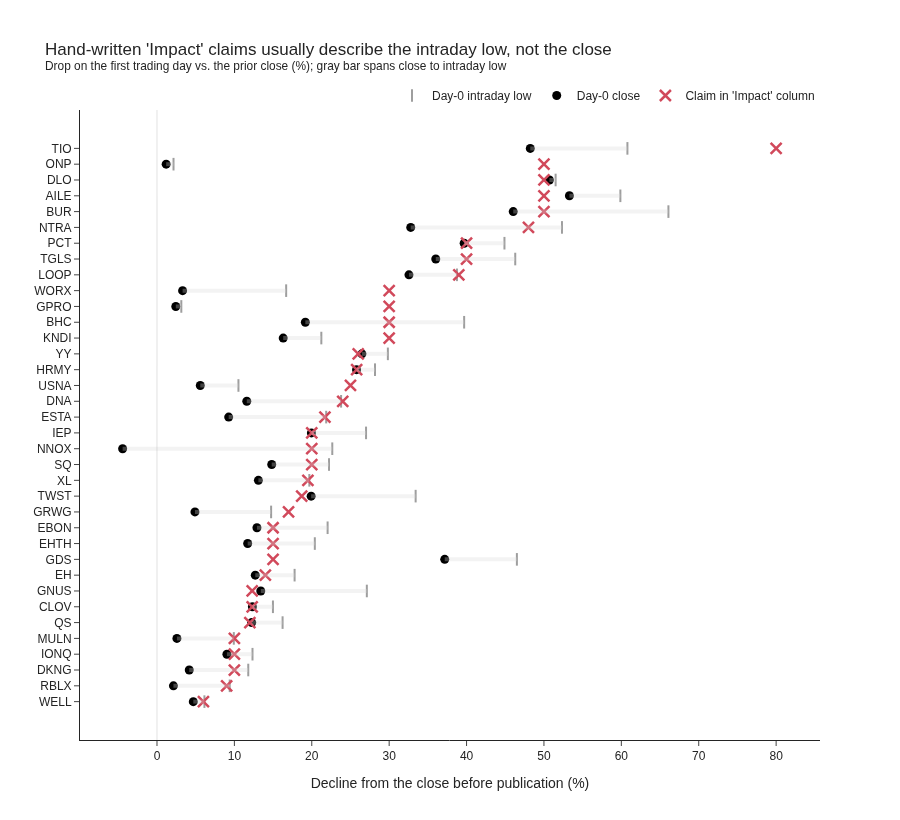

In [19]:
plot = claims.sort_values('claimed_drop')
fig = go.Figure()
for _, r in plot.iterrows():
    fig.add_shape(type='line', x0=r['close_drop'] * 100, x1=r['intraday_drop'] * 100, y0=r['Ticker'], y1=r['Ticker'],
                  line=dict(color=LIGHT_GRAY, width=4))
fig.add_trace(go.Scatter(x=plot['intraday_drop'] * 100, y=plot['Ticker'], mode='markers', name='Day-0 intraday low',
                         marker=dict(color=GRAY, size=9, symbol='line-ns-open', line=dict(width=2)),
                         hovertemplate='%{y}: intraday low -%{x:.1f}%<extra></extra>'))
fig.add_trace(go.Scatter(x=plot['close_drop'] * 100, y=plot['Ticker'], mode='markers', name='Day-0 close',
                         marker=dict(color='black', size=9),
                         hovertemplate='%{y}: close -%{x:.1f}%<extra></extra>'))
fig.add_trace(go.Scatter(x=plot['claimed_drop'] * 100, y=plot['Ticker'], mode='markers', name="Claim in 'Impact' column",
                         marker=dict(color=ACCENT, size=11, symbol='x-thin', line=dict(width=2.5, color=ACCENT)),
                         hovertemplate='%{y}: claimed -%{x:.1f}%<extra></extra>'))
fig.add_vline(x=0, line=dict(color=GRAY, width=1))
fig.update_layout(
    title="Hand-written 'Impact' claims usually describe the intraday low, not the close<br>"
          '<sup>Drop on the first trading day vs. the prior close (%); gray bar spans close to intraday low</sup>',
    xaxis_title='Decline from the close before publication (%)', yaxis_title=None,
    height=820, width=900, legend=dict(orientation='h', yanchor='bottom', y=1.0, xanchor='right', x=1),
    margin=dict(t=110))
fig.show()

- **Most claims describe the worst moment of the day, not where the stock closed.** The median claimed drop is 21%. The median day-0 close was only −13%, but the median intraday low was −22%. Only **12 of 36** claims are met by the closing price, while **29 of 36** are met by the intraday low. That's true even when the note doesn't say "as much as" or "premarket": only 36% of unqualified claims are met at the close.
- Headlines like these naturally quote the most dramatic number of the day. For analysis, the close-to-close return is the measure that an investor could actually have traded at.

A few cases worth a closer look:

In [20]:
cases = ['TIO', 'NTRA', 'USNA', 'ONP', 'GPRO', 'BHC', 'RBLX']
(claims.set_index('Ticker').loc[cases, ['claimed_drop', 'close_drop', 'intraday_drop']]
 .join(events.set_index('Ticker')[['abn_ret_21', 'ret_252']])
 .rename(columns={'claimed_drop': 'claimed drop', 'close_drop': 'day-0 close drop',
                  'intraday_drop': 'day-0 intraday drop', 'abn_ret_21': '1-month abnormal', 'ret_252': '1-year raw return'})
 .style.format('{:.0%}', subset=['claimed drop', 'day-0 close drop', 'day-0 intraday drop'])
 .format('{:+.0%}', subset=['1-month abnormal', '1-year raw return']))

,claimed drop,day-0 close drop,day-0 intraday drop,1-month abnormal,1-year raw return
Ticker,,,,,
TIO,80%,48%,61%,-52%,-100%
NTRA,48%,33%,52%,-31%,-1%
USNA,25%,6%,11%,-26%,+68%
ONP,50%,1%,2%,-51%,-60%
GPRO,30%,2%,3%,-18%,-70%
BHC,30%,19%,40%,-45%,-85%
RBLX,9%,2%,9%,+24%,+206%


- **Tingo (TIO):** the note says the stock lost 80%, "from $0.33 to $0.064". Tingo Group's Nasdaq shares actually went from $2.55 to $1.32 (−48% at the close, −61% at the low), so those prices don't match TIO and probably describe a different Tingo security. The claim was still right in spirit: within a year the stock was down 99.6%.
- **Natera (NTRA):** "down 48%" is the intraday low (−52%). The stock closed −33%, and one year later it was back to roughly flat (−1%).
- **USANA (USNA):** "dropped by over 25%" doesn't match day 0 (−6%). It does match the first month (−26% vs. the market), and a year later the stock was up 68%.
- **Orient Paper (ONP) and GoPro (GPRO):** the 50% and 30% drops did happen, but over months, not on the day (day 0: −1% and −2%). The notes never give a time frame.
- **Valeant (BHC):** "plunges 30%" falls between the close (−19%) and the intraday low (−40%). The long-run claim ("over 90% in the following years") is consistent with the −85% raw return after one year.
- **Roblox (RBLX):** the "more than 9% premarket" drop was real (intraday low −9%), but the stock closed only −2% and was up 206% a year later. That's a reminder that a short report is an opinion, not a verdict.

## Key Findings

- **Almost every target falls on the day of the report.** 37 of 38 studied targets (97%) underperformed the market on day 0, with a median abnormal return of −13.4% (mean −18.2%).
- **The decline keeps going.** The median cumulative abnormal return reaches −27.8% after a month and **−62.2% after a year**. 79% of targets trail the market after a year and 76% are down in absolute terms. 28 of 38 (74%) fell further after day 0. Against IWM or ARKK the effect shrinks (median −50% and −29%) but does not disappear (78–86% still underperform).
- **The first-day drop doesn't predict the 1-year outcome** (Spearman ρ = 0.12). Big day-0 drops at GDS, Natera and Tecnoglass fully reversed. Meanwhile SCWorx (−6% on day 0), Kandi and XL Fleet (−16% and −12%) went on to lose more than 100% vs. the market.
- **Returns are heavily skewed, so medians tell the story.** One winner (Roblox, +190% vs. SPY after a year) pulls the 1-year mean (−48%) far above the median (−62%).
- **Survivorship bias is large and runs in one direction.** 10 of 48 reports (21%) have no price data, including Nikola, the best-known case. Five of the ten targets went bankrupt or were delisted, so the measured losses are likely understated.
- **The hand-compiled "Impact" claims mostly quote intraday lows.** Only 12 of 36 percentage claims are met by the day-0 close, compared with 29 of 36 by the intraday low. One claim (Tingo) quotes prices from a different security.
- **The data needed real cleaning to be usable:** 10 ticker remappings, one wrong publication date (GDS), stray whitespace in the CSV, and three halted or stale price series.

## Case Study Potential

**Verdict: Strong.** The topic is memorable (Nikola, Valeant, Hindenburg Research), and the analysis is a complete, classic event study with a clear and statistically robust result. The data problems are realistic and instructive: survivorship, ticker changes, adjusted prices, a wrong date and hand-written claims that don't match the tape. The dataset is small enough (48 events) for students to inspect every case by hand, yet large enough for distributional statements.

**Suggested framing:** *A portfolio manager at a long-only fund holds a stock that has just been hit by a short-seller report. Should she sell at the open, hold, or buy the dip?* Students build the event study, quantify the typical day-0 and 1-year outcomes and their spread, and decide what the evidence (and its biases) actually supports.

**Analytics skills exercised:** API data collection and caching, data cleaning and validation (whitespace, dates, ticker mapping), time-series alignment on trading-day calendars, event-study design (baseline, abnormal returns, CAR), `groupby`/`pivot`/`melt`, nonparametric tests (Wilcoxon, Mann-Whitney, Spearman), robustness checks (alternative benchmarks), survivorship-bias reasoning, regex text extraction, and visualization (CAR with IQR bands, scatter with reference lines, dumbbell charts).

**Candidate student questions**
1. Why is the baseline the close *before* the publication date rather than the publication-day open? How would results change if reports were released after the close?
2. Ten reports have no price data. Under what assumptions about their outcomes would the median 1-year abnormal return change by more than 10 points?
3. Why does the median CAR keep falling while the mean flattens? Which statistic would you report to an investment committee, and why?
4. The effect shrinks from −62% to −29% when the benchmark changes from SPY to ARKK. What does this say about choosing a benchmark, and which one is most defensible?
5. Is a −62% median abnormal return over a year evidence that markets are inefficient, or could a short seller still lose money on these trades (borrow costs, squeezes, timing)?

**Main data limitations:** a small, hand-picked list of reports (not all reports by these firms, so there is selection bias toward famous wins). 21% of reports are missing because of survivorship. Only daily closes and lows are available, with no intraday timing of publication. The abnormal returns use a simple market-adjusted model with no risk or style adjustment. And the "Impact" column is unsourced narrative text.